# Quick fongbe sentiment analysis pipeline

In [1]:
from pathlib import Path

DATASET_PATH = Path("../data/French_Fongbe_Sentiment_Dataset.csv")

In [2]:
from experiments.fon_sentiment_classification.utils import load_dataset, get_pipeline, train, evaluate

In [3]:
# load and prepocess dataset
x_train, x_val, y_train, y_val = load_dataset(DATASET_PATH)

2026-07-13 19:23:26.226 | SUCCESS  | experiments.fon_sentiment_classification.utils:load_dataset:34 - Dataset loaded and preprocessed successfully.


### using naive bayes classifier

In [4]:
# get pipeline
pipeline_nb = get_pipeline()
# train model
model_nb = train(pipeline_nb, x_train, y_train)

2026-07-13 19:23:26.339 | INFO     | experiments.fon_sentiment_classification.utils:get_pipeline:40 - Creating pipeline: naive_bayes
2026-07-13 19:23:26.341 | INFO     | experiments.fon_sentiment_classification.utils:train:58 - Model training started...
2026-07-13 19:23:27.078 | SUCCESS  | experiments.fon_sentiment_classification.utils:train:60 - Model training completed...


In [5]:
# evaluate model
print(evaluate(model_nb, x_val, y_val))

2026-07-13 19:23:27.133 | INFO     | experiments.fon_sentiment_classification.utils:evaluate:66 - Getting performance metrics


              precision    recall  f1-score   support

           0       0.71      0.59      0.65       706
           1       0.68      0.81      0.74      1044
           2       0.73      0.66      0.69       843

    accuracy                           0.70      2593
   macro avg       0.71      0.69      0.69      2593
weighted avg       0.70      0.70      0.70      2593



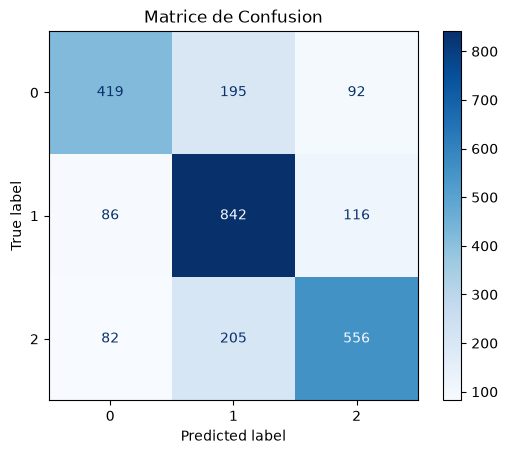

In [6]:
from experiments.fon_sentiment_classification.utils import plot_metrics
plot_metrics(model_nb, x_val, y_val)

### using random forest classifier

In [7]:
rf_pipeline = get_pipeline(model_type="random_forest")
model_rf = train(rf_pipeline, x_train, y_train)

2026-07-13 19:23:27.750 | INFO     | experiments.fon_sentiment_classification.utils:get_pipeline:40 - Creating pipeline: random_forest
2026-07-13 19:23:27.751 | INFO     | experiments.fon_sentiment_classification.utils:train:58 - Model training started...
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.4s


building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   23.5s finished
2026-07-13 19:23:52.011 | SUCCESS  | experiments.fon_sentiment_classification.utils:train:60 - Model training completed...


In [8]:
print(evaluate(model_rf, x_val, y_val))

2026-07-13 19:23:52.023 | INFO     | experiments.fon_sentiment_classification.utils:evaluate:66 - Getting performance metrics
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


              precision    recall  f1-score   support

           0       0.71      0.60      0.65       706
           1       0.69      0.80      0.74      1044
           2       0.70      0.66      0.68       843

    accuracy                           0.70      2593
   macro avg       0.70      0.69      0.69      2593
weighted avg       0.70      0.70      0.70      2593



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


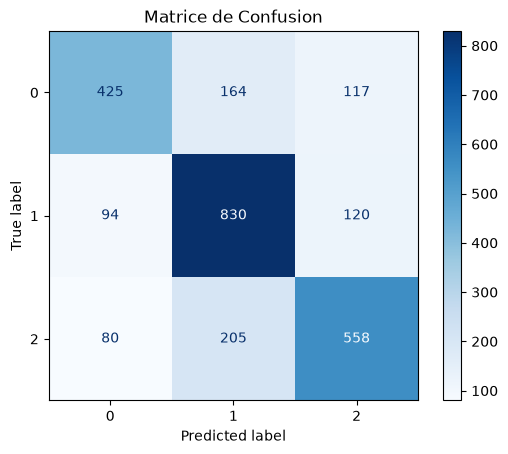

In [9]:
plot_metrics(model_rf, x_val, y_val)

### testing the model on a new sentences

In [12]:
phrases = [
    "Un yi wan nu e a.",
    "Un yí wǎn nú we",
    "Égbé ɔ‚ hwenu ɔ nyɔ .",
    "Un gbɛ wan nu ji",
    "Roger ko ɖò azɔn jɛ wɛ sín hweɖenu ɖíe.",
    "Mi kɛnklɛn bo ɖexlɛ́ ɖɔ emi ɖò finɛ gbɔn xósin nina gblamɛ.",
    "Un jló na ɖɔ xó klewun xá gǎn e nɔ kpé nukún dó azɔ̌ ɔ wu é, bo na ɖɔ xó dó nǔ taji e kàn mɛɖesunɔ é ɖé jí.",
    "Ðǒtó ganji"
]

In [13]:
from experiments.fon_sentiment_classification.utils import predict

print(f"Naive bayes model predictions")
print("-"*10)
for phrase in phrases:
    print(f"Phrase: {phrase} | Sentiment: {predict(model_nb, phrase)}")

print(f"\nRandom forest model predictions")
print("-"*10)
for phrase in phrases:
    print(f"Phrase: {phrase} | Sentiment: {predict(model_rf, phrase)}")

2026-07-13 19:25:51.843 | INFO     | experiments.fon_sentiment_classification.utils:predict:86 - Predicting sentiment for sentence
2026-07-13 19:25:51.846 | INFO     | experiments.fon_sentiment_classification.utils:predict:86 - Predicting sentiment for sentence
2026-07-13 19:25:51.848 | INFO     | experiments.fon_sentiment_classification.utils:predict:86 - Predicting sentiment for sentence
2026-07-13 19:25:51.850 | INFO     | experiments.fon_sentiment_classification.utils:predict:86 - Predicting sentiment for sentence
2026-07-13 19:25:51.853 | INFO     | experiments.fon_sentiment_classification.utils:predict:86 - Predicting sentiment for sentence
2026-07-13 19:25:51.856 | INFO     | experiments.fon_sentiment_classification.utils:predict:86 - Predicting sentiment for sentence
2026-07-13 19:25:51.858 | INFO     | experiments.fon_sentiment_classification.utils:predict:86 - Predicting sentiment for sentence
2026-07-13 19:25:51.861 | INFO     | experiments.fon_sentiment_classification.utils

Naive bayes model predictions
----------
Phrase: Un yi wan nu e a. | Sentiment: Negative
Phrase: Un yí wǎn nú we | Sentiment: Positive
Phrase: Égbé ɔ‚ hwenu ɔ nyɔ . | Sentiment: Positive
Phrase: Un gbɛ wan nu ji | Sentiment: Negative
Phrase: Roger ko ɖò azɔn jɛ wɛ sín hweɖenu ɖíe. | Sentiment: Negative
Phrase: Mi kɛnklɛn bo ɖexlɛ́ ɖɔ emi ɖò finɛ gbɔn xósin nina gblamɛ. | Sentiment: Positive
Phrase: Un jló na ɖɔ xó klewun xá gǎn e nɔ kpé nukún dó azɔ̌ ɔ wu é, bo na ɖɔ xó dó nǔ taji e kàn mɛɖesunɔ é ɖé jí. | Sentiment: Positive
Phrase: Ðǒtó ganji | Sentiment: Positive

Random forest model predictions
----------
Phrase: Un yi wan nu e a. | Sentiment: Negative
Phrase: Un yí wǎn nú we | Sentiment: Negative
Phrase: Égbé ɔ‚ hwenu ɔ nyɔ . | Sentiment: Positive
Phrase: Un gbɛ wan nu ji | Sentiment: Negative
Phrase: Roger ko ɖò azɔn jɛ wɛ sín hweɖenu ɖíe. | Sentiment: Negative
Phrase: Mi kɛnklɛn bo ɖexlɛ́ ɖɔ emi ɖò finɛ gbɔn xósin nina gblamɛ. | Sentiment: Positive
Phrase: Un jló na ɖɔ xó klewun

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s


Phrase: Ðǒtó ganji | Sentiment: Positive


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
